# Day 024 · 撮合机制全景
**Matching Mechanics** · 阶段 P1 · 量化基础

> 撮合引擎是交易所的心脏 — 所有买卖单都要经过它才能成交。今天我们做三件事:① 自己用 Python 写一个简易撮合引擎(支持限价 / 市价 / 撤单三种基本操作),把『订单簿数据结构 + 撮合规则』从内部角度看清楚;② 对比集合竞价和连续竞价两种模式,理解为什么 A 股开盘 9:15-9:25 是集合竞价、9:30 之后才是连续竞价;③ 对比 FIFO 价格-时间优先 和 pro-rata 按比例分配 两种规则,看清楚同样订单簿下两种规则产生的完全不同执行结果。最后讲一些有意思的边缘情况:自成交禁令、错单 fat finger、闪崩、断路器 LULD。这是从外部视角看市场走向内部视角理解市场的关键一步。

---

**课件生成日期:** 2026-05-17  ·  **建议学习时长:** 20 分钟

学习路径建议:1)先看视频建立直觉 → 2)阅读本 notebook 跑代码 → 3)看 PDF 课件复习要点 → 4)做自测题

## 🔧 第一步:环境自检 + 自动安装

**第一次拿到这份 notebook,请先运行下面这一格。** 它会:
1. 检查所有需要的 Python 包,缺什么自动 `pip install` 装上
2. 注入中文字体到 matplotlib(让图标不出乱码)
3. 跑完看到 `✓ 环境就绪` 就可以继续下面的代码

> 这一格只在第一次跑要等几十秒,后面再开 notebook 就秒过。

In [1]:
# === 环境自检 + 自动安装(运行此单元格即可) ===
# 检测缺失的库 → 自动 pip 安装 → 注入中文字体 → 一行命令搞定
import importlib
import subprocess
import sys
import os

REQUIRED = ["matplotlib", "numpy", "numpy_financial", "pandas", "scipy", "sklearn", "statsmodels", "yfinance"]
PIP_NAME = {
    "sklearn": "scikit-learn",
    "cv2": "opencv-python",
    "PIL": "Pillow",
    "bs4": "beautifulsoup4",
    "yaml": "PyYAML",
}

missing = []
for mod in REQUIRED:
    try:
        importlib.import_module(mod)
    except ImportError:
        missing.append(PIP_NAME.get(mod, mod))

if missing:
    print(f"⏳ 缺少 {len(missing)} 个包,正在自动安装:{missing}")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])
    print("✓ 安装完成")
else:
    print(f"✓ 所有 {len(REQUIRED)} 个必需库已就绪")

# === 中文字体配置(让 matplotlib 不出乱码) ===
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

CJK_FONT_PATHS = [
    "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc",  # Linux/WSL
    "C:/Windows/Fonts/msyh.ttc",                               # Windows 微软雅黑
    "C:/Windows/Fonts/simhei.ttf",                             # Windows 黑体
    "/System/Library/Fonts/PingFang.ttc",                      # macOS 苹方
    "/System/Library/Fonts/STHeiti Medium.ttc",                # macOS 黑体
]
for p in CJK_FONT_PATHS:
    if os.path.exists(p):
        fm.fontManager.addfont(p)
        print(f"✓ 中文字体已加载:{os.path.basename(p)}")
        break
plt.rcParams["font.sans-serif"] = ["Noto Sans CJK JP", "Microsoft YaHei",
                                    "PingFang SC", "SimHei", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False
print("✓ 环境就绪 — 现在可以跑下面的代码单元格")


✓ 所有 8 个必需库已就绪
✓ 中文字体已加载:NotoSansCJK-Regular.ttc
✓ 环境就绪 — 现在可以跑下面的代码单元格


## 学习目标

- 用 Python 从零写一个支持限价 / 市价 / 撤单的撮合引擎,看懂 LOB 数据结构 + 撮合循环
- 对比集合竞价 vs 连续竞价 — 集合竞价用单一清算价、连续竞价按时间优先逐笔撮合
- 对比 FIFO 价格-时间优先 vs pro-rata 按比例分配,看清楚两种规则下相同订单簿产生不同执行结果
- 理解自成交禁令 / 错单 / 闪崩 / 断路器(LULD)等边缘情况,知道交易所如何处理异常
- 看懂为什么 A 股 / 港股 / 美股 / 期货 / 加密的撮合细节不同,知道用对应规则做策略时该避开什么坑

## 历史背景:撮合机制 — 从人肉撮合到光速撮合的两百年演化

撮合机制不是新东西 — 任何有买卖双方的市场都需要某种撮合规则。但『可量化、可程序化、可在毫秒级公平执行』的现代撮合引擎是一段两百年演化史。

**1792 年纽约梧桐树协议**:24 个 broker 在华尔街梧桐树下签订协议,约定佣金率和撮合规则。这是 NYSE 的起源。撮合方式是『叫卖』— broker 当面喊价,撮合成交。原始但有效。

**1869 年报价机**:Thomas Edison 改进电报技术,股价能通过电报传到全国。但撮合仍由 NYSE 内部 specialist 用纸笔完成。

**1971 年 NASDAQ 电子化报价**:报价集中显示在屏幕上,但撮合仍由 dealer 完成。NASDAQ 是 dealer-driven 市场,跟 NYSE 的 specialist-driven 不同 — 都是人肉中介。

**1996 年 Island ECN**:第一个完全无人化的电子撮合系统。订单进入系统后自动按价格-时间优先撮合,没有 specialist 也没有 dealer。这是撮合从『人肉』走向『代码』的革命。

**2000-2010 年高频化**:撮合引擎延迟从毫秒级降到微秒级再降到纳秒级。CME 期货撮合 2010 年达到 50 微秒,2020 年降到 10 微秒以下。高频做市商投资天量算力 + 直连机房抢这十几微秒。

**2010 年 Flash Crash + LULD 断路器**:撮合引擎本身没问题,但深度脆弱性暴露。SEC 强制全市场上线 Limit Up Limit Down 断路器:任何股价 5 分钟内偏离参考价 5-10% 自动暂停 5 秒。这是『撮合规则从纯效率走向稳健性补偿』的转折点。

今天主流交易所撮合引擎已经成为最复杂的工程系统之一。CME 每秒撮合数百万笔订单 / 上交所 / 深交所每秒撮合百万级 / 币安每秒撮合千万级。撮合规则在效率、公平、稳健性之间不断权衡。



## 核心概念

下面每一节是听完视频后回头细读的内容。

### 1. 撮合引擎核心循环 — 订单簿 + 撮合 + 成交记录

**撮合引擎的最小完整实现**只需要三个组件:

**Component 1 — 订单簿数据结构**
用两个排序字典(或平衡树 / heap)分别维护买盘和卖盘。Python 简化版可以用 `dict[price -> deque(qty, order_id)]`,但生产系统用 C++ red-black tree 实现毫秒级随机访问。

**Component 2 — 撮合循环**(matching engine)
每来一个新订单,引擎执行三步:
1. 检查能否立刻成交(限价单要看 BBO 是否能 cross,市价单一定能成交)
2. 如果能成交,从对手盘最优档开始 sweep,按价格-时间优先消耗深度
3. 剩余部分如果是限价单,挂进订单簿排队;如果是市价单,撤销剩余(IOC 行为)

**Component 3 — 成交记录(trade log)**
每笔成交记录时间戳、价格、数量、买卖方向、买方 / 卖方订单 ID。这是日终对账和监管报送的基础。

**生产系统的额外复杂性**:
- 多线程并发处理(每秒百万级订单)
- 持久化(订单簿状态断电恢复)
- 自成交禁令(同账户买卖单不能直接成交)
- 错单熔断(单笔订单超过阈值自动拒绝)
- 多 venue 路由(订单簿在多个数据中心同步)

但核心逻辑就这三块,任何撮合引擎都是这三块的工程化展开。

```
撮合三步:① 检查能否 cross ② sweep 对手盘消耗深度 ③ 剩余挂进 LOB 或撤销
```

> **举例:** 假设买盘 best bid 100.00 元挂 200 股 / 卖盘 best ask 100.01 元挂 300 股。新来一个限价买单 100.02 元 500 股。撮合引擎:① 100.02 > 100.01 能 cross;② 吃卖一 300 股按 100.01,剩余 200 股进 LOB 挂在 100.02 元;③ 现在 BBO 变成 100.02 / 等待新卖盘。


### 2. 集合竞价 vs 连续竞价 — 两种撮合模式

**集合竞价(call auction)** — 一段时间内接收所有订单但不立刻撮合。时段结束时引擎计算一个『清算价』,让最大成交量发生,所有能成交的订单按这个统一价成交。

**清算价规则**:取使『成交量最大』的那个价格;如果多个价格成交量相同,取『未成交订单数最小』的;再不行取『最接近上一次集合竞价价』的。这套规则在 A 股 / 港股 / 欧股都通用。

**集合竞价的核心优势**:
- 单一价格成交,公平(同一时刻所有人同样价)
- 集中流动性,降低开盘 / 收盘瞬间波动
- 不暴露大单意图(订单在时段内挂着但不显示对手成交记录)

**集合竞价的应用场景**:
- A 股开盘 9:15-9:25(尾盘 14:57-15:00 也是)
- 港股开盘集合竞价 9:00-9:30
- 欧股开盘 / 收盘 5 分钟集合竞价

**连续竞价(continuous auction)** — 每个订单到达后立刻进入撮合循环,有匹配就立刻成交。这是日常交易时段的主要模式。

**连续竞价的优势**:即时性 / 高效率 / 价格连续

**连续竞价的劣势**:大单立刻暴露意图,可能被前置 / 反向操作

**实战含义**:
- 集合竞价不能撤单后立刻重挂(A 股 9:20 后撤单受限)
- 集合竞价想精准成交要在结束前 30 秒提交
- 连续竞价是主战场,99% 量化策略都在这个时段执行

```
集合:max(成交量) 选清算价 / 连续:逐笔到达立刻撮合
```

> **举例:** A 股开盘集合竞价:9:25 时段结束,引擎扫描所有挂单。假设 100.00 元能成交 5000 股、99.99 元能成交 6000 股、99.98 元能成交 5500 股。清算价取 99.99 元(成交量最大),所有能在 99.99 成交的单全部按 99.99 成交。9:30 之后转入连续竞价,每笔新单立刻撮合。


### 3. FIFO 价格-时间优先 vs pro-rata 按比例分配

**FIFO 价格-时间优先**(几乎所有现货市场标配):
- 价格优先:出价好的先成交
- 时间优先(同价档内):先挂的先成交
- 适用于:A 股 / 美股 / 港股 / 日股 / 加密

**FIFO 的特点**:
- 单个订单要么全部成交、要么部分成交、要么留在队列
- 排队位置决定成交概率,因此 HFT 拼命抢 rank 1
- 散户挂同价单只能排队尾

**pro-rata 按比例分配**(某些期货 / 国债市场用):
- 同一价格档内,新到的对手单按各挂单数量比例分配给所有挂单
- 例:档内 A 挂 100 股 / B 挂 200 股 / C 挂 700 股,合计 1000 股。新来 500 股市价对手单,A 分 50 股、B 分 100 股、C 分 350 股(按 10:20:70 比例)
- 适用于:CME 欧元、英镑期货 / 部分国债期货 / 部分电力市场

**pro-rata 的特点**:
- 不存在排队优势,大挂单分到大份额
- 鼓励挂大单(否则只能分到小份额)
- 平均成交概率不取决于到达时间

**为什么期货用 pro-rata,股票用 FIFO**:
- 期货是『同质标的』(每张合约一样),pro-rata 鼓励 deep liquidity
- 股票是『独立公司价值』,FIFO 激励市场参与者快速反应新信息
- pro-rata 鼓励『虚假大单』(挂大但实际不想全成交),需要额外反操纵规则

**实战含义**:做 CME 利率期货策略时不能套用美股策略 — 排队位置在 pro-rata 下完全不重要。你 100 股 vs 别人 10000 股挂同价,你只能分到 1%。

```
FIFO:rank = 时间顺序;pro-rata:分配比例 = 你的挂单 / 同档总挂单
```

> **举例:** CME E-mini SP 期货某档挂 10 个 LO,各 100 / 200 / 50 / 400 / 800 / 100 / 600 / 300 / 200 / 150 股,合计 2900 股。新来对手单 1000 股市价。pro-rata 分配:每个挂单按 100/2900、200/2900...比例分,分别拿到 34、69、17、138、276、34、207、103、69、52 股(总 999 股,1 股的零头按规则给某个挂单)。


### 4. 自成交禁令 + 错单 + Cancel-Replace

**自成交禁令(self-trade prevention,STP)**:同一账户的买卖单不能直接成交。这是反操纵的核心规则。

**为什么禁止自成交**:
- 自买自卖能虚增成交量(刷量)误导市场
- 能控制 last price(收盘价操纵)
- SEC / 上交所明令禁止,违规罚款 + 撤销资格

**STP 实现方式**:
- 撮合引擎检测撮合双方账户 ID,相同则跳过撮合
- 该笔订单被推进 LOB 等下一笔对手
- 个别交易所(NASDAQ)对 STP 提供多种处理选项:取消买方 / 取消卖方 / 取消两方 / 减小数量

**错单(fat finger)处理**:
- 多按一个零:本来卖 100 股变成卖 1000 股 → 巨额冲击
- 多按一个零:本来 100 元变成 1000 元 → 价格异常
- 撮合引擎设阈值(单笔超过历史平均 X 倍直接拒绝)
- 错单成交后可申请『错单撤销』,但需要交易所审核,通常很难撤回

**Cancel-Replace(撤改)**:
- 撤掉旧单 + 挂新单 = 两个独立操作
- 真实撤改是『先在新价挂上,再撤旧』,避免撤了挂不上的尴尬
- 高频做市每秒可能 cancel-replace 数千次维护 BBO 位置

**实战含义**:
- 散户挂单前认真核对价格 + 数量,错单成交后撤销几乎不可能
- 自动化策略必须实现 STP 逻辑,否则可能误成自买自卖
- 极端情况下撮合引擎可能短暂故障,挂单状态不确定,这时候不要慌乱重挂

```
STP:撮合双方 account_id 相同 → 跳过 / 错单阈值:单笔 qty > 历史均量 × N → 拒绝
```

> **举例:** 2010 年 5 月 6 日 Flash Crash 当天,某机构卖 4 万亿 SP 期货时算法把 41 亿美元拆错没设单量上限。一笔 75000 张合约的卖单一次砸下,触发雪崩。事后 SEC 强制所有交易所上 LULD 断路器 + 单笔上限。今天 CME 任何单笔订单超过 2 个标准差自动拒绝。


### 5. 断路器 LULD + 闪崩防护

**Limit Up Limit Down(LULD)**(2010 Flash Crash 后强制上线):

**核心规则**:任何美股 5 分钟内偏离参考价超过 5-10%(看股价 + 流动性等级)自动暂停 5 秒撮合。参考价是过去 5 分钟成交均价。

**LULD 触发流程**:
1. 价格触及上 / 下限带(price band)
2. 撮合引擎进入『限价状态』(limit state)15 秒
3. 15 秒内能反向回到价格带内 → 继续交易;不行 → 暂停 5 秒
4. 5 秒后恢复连续撮合,价格带重新计算

**A 股的等价机制 — 涨跌停**:
- 主板:±10% / 创业板:±20% / 科创板:±20%
- 涨跌停板上撮合规则有特殊性,跌停板上『卖盘排队但没有买盘』,所有挂卖单按时间排队等待买家
- 上交所对涨停板上的特殊撮合细节比较隐蔽,导致涨停首日封单巨大但撮合极少

**港股没有涨跌停**(但 2016 年起加了 LULD-like 机制):
- 任何股价 5 分钟内偏离参考价超过 10% 暂停 5 分钟
- 之前港股闪崩很常见,2016 改革后稳定不少

**加密市场没有断路器**:
- 币安 / Coinbase 等加密交易所没有强制断路器(可选『冷却期』但很少触发)
- 加密闪崩频繁,2022 年 5 月 LUNA 5 天暴跌 99.99%,撮合引擎正常运行但价格一路下跌
- 这是加密对比传统市场最大的风险点之一

**实战含义**:
- 写策略要考虑 LULD / 涨跌停 / 闪崩三种异常状态,处理逻辑要分开
- 不要在异常状态下追单,流动性可能瞬间消失
- 加密策略要自己实现『熔断逻辑』(单日亏损超过 X% 暂停交易),交易所不会帮你

```
LULD:|price_t - price_ref(t-5min)| > 5-10% → 5 秒暂停撮合
```

> **举例:** 2010 年 5 月 6 日 14:32-14:45 美股下跌 9%,P&G 股价 36 分钟内从 60 美元跌到 39 美元(33%)。事后 SEC 强制 LULD,2012 年 4 月上线。2015 年 8 月 24 日开盘 5 分钟内 LULD 触发 1278 次,但市场仍跌 7% — 这是 LULD 在系统性冲击下仍然失效的反面教训。


## 实操:简易撮合引擎(限价 + 市价 + 撤单)+ 集合竞价 + FIFO vs pro-rata 对比

下面这段代码跟视频里讲解的 highlights 是一致的,可以**直接 Run All** 看结果。

**依赖安装:**
```bash
pip install pandas numpy matplotlib yfinance akshare statsmodels
```


初始 BBO 买一 99.99 卖一 100.01
初始挂单数:买盘 10 卖盘 10

模拟结束:撮合引擎产生成交 243 笔
最终 BBO 买一 99.99 卖一 100.0
最终挂单数:买盘 82 卖盘 76

========== 集合竞价示例 ==========
       候选价     买量(≥p)     卖量(≤p)        成交量
     99.95       5600        200        200
    100.00       4600       1400       1400
    100.05       2600       3400       2600
    100.10       1800       4400       1800
    100.15        300       5200        300

清算价 = 100.05 总成交量 = 2600(集合竞价单一价撮合)

========== FIFO vs pro-rata 撮合对比 ==========

FIFO(价格-时间优先)收到对手单 500 股:
  A 挂 100 股(rank 1),分到 100 股
  B 挂 200 股(rank 2),分到 200 股
  C 挂 700 股(rank 3),分到 200 股

pro-rata(按比例分配)收到对手单 500 股:
  A 挂 100 股(占比 10.0%),分到 50 股
  B 挂 200 股(占比 20.0%),分到 100 股
  C 挂 700 股(占比 70.0%),分到 350 股

图已保存 chart_01.png


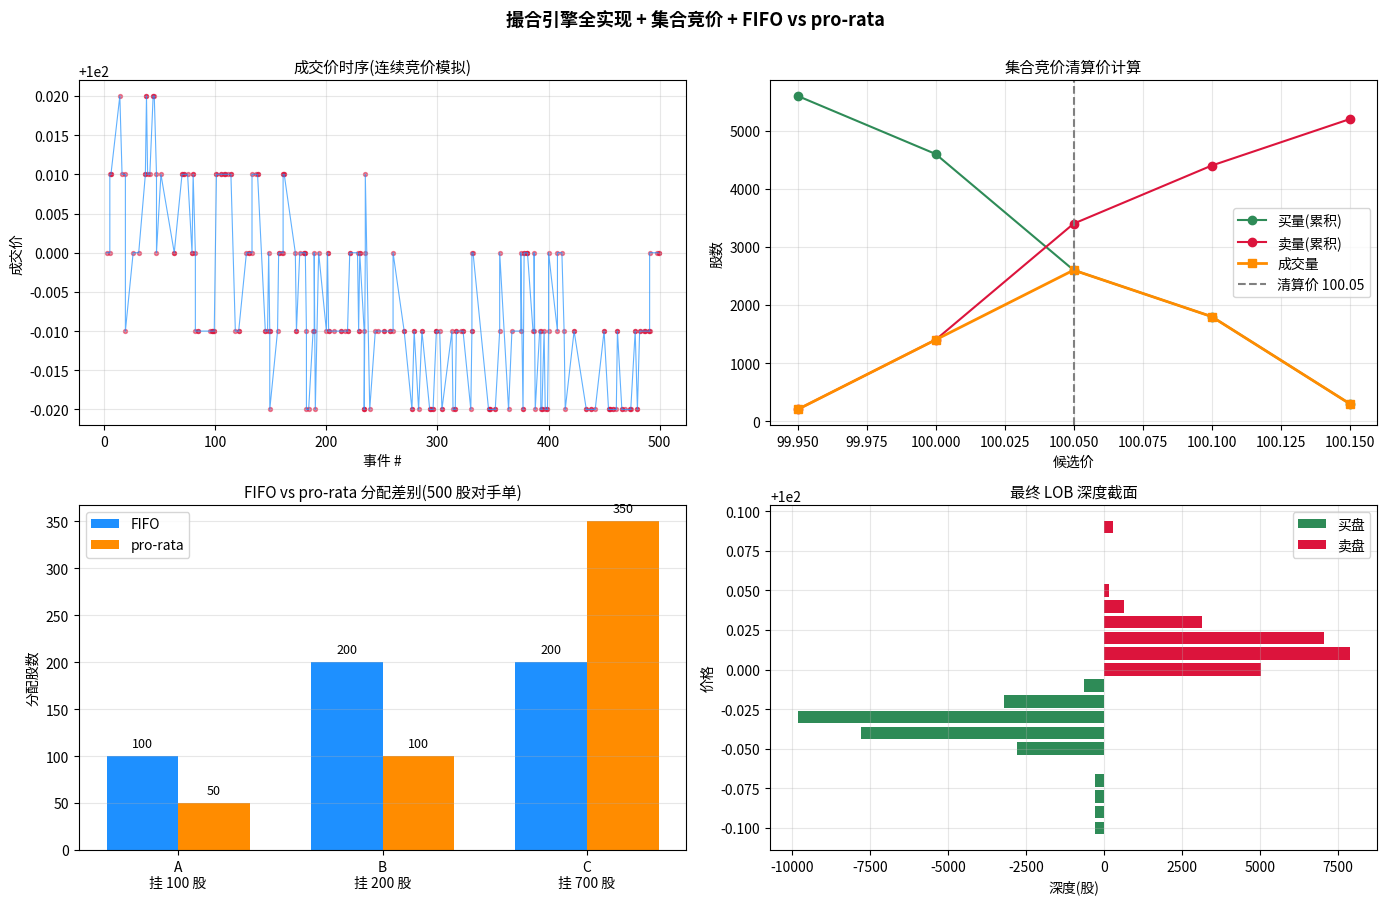

In [2]:
# day_024_matching_engine.py — 撮合引擎全实现
import numpy as np
import matplotlib.pyplot as plt
from collections import deque
from dataclasses import dataclass
np.random.seed(42)

# ============ 1. 订单和成交数据结构 ============
@dataclass
class Order:
    oid: int
    side: str    # 'B' / 'S'
    otype: str   # 'LO' / 'MO'
    price: float
    qty: int
    account: str
    ts: int

@dataclass
class Trade:
    ts: int
    price: float
    qty: int
    buy_oid: int
    sell_oid: int
    side_aggressor: str

# ============ 2. 撮合引擎 ============
class MatchingEngine:
    def __init__(self):
        self.bids = {}   # price -> deque(Order)
        self.asks = {}   # price -> deque(Order)
        self.trades = []
        self.next_oid = 0
    def best_bid(self):
        return max(self.bids.keys()) if self.bids else None
    def best_ask(self):
        return min(self.asks.keys()) if self.asks else None
    def submit(self, side, otype, price, qty, account, ts):
        order = Order(self.next_oid, side, otype, price, qty, account, ts)
        self.next_oid += 1
        return self.match(order)
    def match(self, order):
        """撮合循环:看能不能立刻吃对手盘,剩余进 LOB"""
        if order.side == 'B':
            book = self.asks; my_book = self.bids
            cross = lambda p, my: order.otype == 'MO' or order.price >= p
            sort_key = lambda: sorted(book.keys())
        else:
            book = self.bids; my_book = self.asks
            cross = lambda p, my: order.otype == 'MO' or order.price <= p
            sort_key = lambda: sorted(book.keys(), reverse=True)
        for p in sort_key():
            if not cross(p, order): break
            queue = book[p]
            while queue and order.qty > 0:
                opp = queue[0]
                # STP self-trade prevention
                if opp.account == order.account:
                    queue.popleft()
                    continue
                take = min(opp.qty, order.qty)
                trade_price = opp.price
                buy_oid = order.oid if order.side == 'B' else opp.oid
                sell_oid = opp.oid if order.side == 'B' else order.oid
                self.trades.append(Trade(order.ts, trade_price, take, buy_oid, sell_oid, order.side))
                order.qty -= take; opp.qty -= take
                if opp.qty == 0:
                    queue.popleft()
            if not queue: del book[p]
            if order.qty == 0: break
        # 剩余进 LOB(仅 LO,MO 直接 IOC 撤销)
        if order.qty > 0 and order.otype == 'LO':
            if order.price not in my_book:
                my_book[order.price] = deque()
            my_book[order.price].append(order)
        return order.oid
    def cancel(self, oid):
        for book in [self.bids, self.asks]:
            for p, queue in list(book.items()):
                for i, o in enumerate(queue):
                    if o.oid == oid:
                        del queue[i]
                        if not queue: del book[p]
                        return True
        return False

# ============ 3. 模拟连续竞价 ============
engine = MatchingEngine()
# 初始 seed LOB
for i in range(10):
    engine.submit('B', 'LO', round(100.00 - 0.01*(i+1), 2), 300, 'MM1', 0)
    engine.submit('S', 'LO', round(100.00 + 0.01*(i+1), 2), 300, 'MM1', 0)
print(f'初始 BBO 买一 {engine.best_bid():.2f} 卖一 {engine.best_ask():.2f}')
print(f'初始挂单数:买盘 {sum(len(q) for q in engine.bids.values())} 卖盘 {sum(len(q) for q in engine.asks.values())}')

# 跑 500 个事件
for t in range(1, 501):
    e = np.random.choice(['LO_B','LO_S','MO_B','MO_S','CANCEL'],
                          p=[0.30,0.30,0.15,0.15,0.10])
    if e == 'LO_B':
        p = round((engine.best_ask() or 100.05) - 0.01 * np.random.randint(1, 5), 2)
        engine.submit('B', 'LO', p, np.random.randint(100, 500), f'T{t}', t)
    elif e == 'LO_S':
        p = round((engine.best_bid() or 99.95) + 0.01 * np.random.randint(1, 5), 2)
        engine.submit('S', 'LO', p, np.random.randint(100, 500), f'T{t}', t)
    elif e == 'MO_B':
        engine.submit('B', 'MO', 0, np.random.randint(100, 300), f'T{t}', t)
    elif e == 'MO_S':
        engine.submit('S', 'MO', 0, np.random.randint(100, 300), f'T{t}', t)
    else:  # CANCEL random LO
        all_orders = []
        for book in [engine.bids, engine.asks]:
            for q in book.values(): all_orders.extend(q)
        if all_orders:
            tgt = np.random.choice(all_orders)
            engine.cancel(tgt.oid)

print(f'\n模拟结束:撮合引擎产生成交 {len(engine.trades)} 笔')
print(f'最终 BBO 买一 {engine.best_bid()} 卖一 {engine.best_ask()}')
print(f'最终挂单数:买盘 {sum(len(q) for q in engine.bids.values())} 卖盘 {sum(len(q) for q in engine.asks.values())}')

# ============ 4. 集合竞价模拟 ============
print('\n========== 集合竞价示例 ==========')
# 想象 9:15-9:25 期间,所有挂单堆积,9:25 一次性计算清算价
buy_orders = [(99.95, 1000), (100.00, 2000), (100.05, 800), (100.10, 1500), (100.15, 300)]
sell_orders = [(99.95, 200), (100.00, 1200), (100.05, 2000), (100.10, 1000), (100.15, 800)]

# 计算每个候选价的成交量
candidate_prices = sorted(set([p for p,_ in buy_orders] + [p for p,_ in sell_orders]))
print(f'{"候选价":>10} {"买量(≥p)":>10} {"卖量(≤p)":>10} {"成交量":>10}')
best_price = None; best_vol = 0
for p in candidate_prices:
    buy_v = sum(q for bp, q in buy_orders if bp >= p)
    sell_v = sum(q for sp, q in sell_orders if sp <= p)
    deal_v = min(buy_v, sell_v)
    print(f'{p:>10.2f} {buy_v:>10} {sell_v:>10} {deal_v:>10}')
    if deal_v > best_vol:
        best_vol = deal_v; best_price = p
print(f'\n清算价 = {best_price:.2f} 总成交量 = {best_vol}(集合竞价单一价撮合)')

# ============ 5. FIFO vs pro-rata 对比 ============
print('\n========== FIFO vs pro-rata 撮合对比 ==========')
queue_orders = [('A', 100, 1), ('B', 200, 2), ('C', 700, 3)]   # (account, qty, time)
incoming_qty = 500

# FIFO
print(f'\nFIFO(价格-时间优先)收到对手单 {incoming_qty} 股:')
remaining = incoming_qty; allocations_fifo = {}
for acc, q, t in queue_orders:
    if remaining <= 0: break
    take = min(q, remaining)
    allocations_fifo[acc] = take
    remaining -= take
    print(f'  {acc} 挂 {q} 股(rank {t}),分到 {take} 股')

# pro-rata
print(f'\npro-rata(按比例分配)收到对手单 {incoming_qty} 股:')
total_q = sum(q for _,q,_ in queue_orders)
allocations_pro = {}
for acc, q, t in queue_orders:
    share = q / total_q
    take = int(round(incoming_qty * share))
    allocations_pro[acc] = take
    print(f'  {acc} 挂 {q} 股(占比 {share*100:.1f}%),分到 {take} 股')

# ============ 6. 可视化 ============
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# 6.1 成交价时序
trade_times = [t.ts for t in engine.trades]
trade_prices = [t.price for t in engine.trades]
axes[0,0].plot(trade_times, trade_prices, '-', color='#1e90ff', linewidth=0.8, alpha=0.7)
axes[0,0].scatter(trade_times, trade_prices, s=8, color='#dc143c', alpha=0.5)
axes[0,0].set_title('成交价时序(连续竞价模拟)', fontsize=11)
axes[0,0].set_xlabel('事件 #'); axes[0,0].set_ylabel('成交价')
axes[0,0].grid(alpha=0.3)

# 6.2 集合竞价清算价曲线
buy_vols = [sum(q for bp, q in buy_orders if bp >= p) for p in candidate_prices]
sell_vols = [sum(q for sp, q in sell_orders if sp <= p) for p in candidate_prices]
deal_vols = [min(b, s) for b, s in zip(buy_vols, sell_vols)]
axes[0,1].plot(candidate_prices, buy_vols, 'o-', label='买量(累积)', color='#2e8b57')
axes[0,1].plot(candidate_prices, sell_vols, 'o-', label='卖量(累积)', color='#dc143c')
axes[0,1].plot(candidate_prices, deal_vols, 's-', label='成交量', color='#ff8c00', linewidth=2)
axes[0,1].axvline(best_price, color='gray', linestyle='--', label=f'清算价 {best_price:.2f}')
axes[0,1].set_title('集合竞价清算价计算', fontsize=11)
axes[0,1].set_xlabel('候选价'); axes[0,1].set_ylabel('股数')
axes[0,1].grid(alpha=0.3); axes[0,1].legend()

# 6.3 FIFO vs pro-rata 分配对比
accs = [acc for acc,_,_ in queue_orders]
fifo_vals = [allocations_fifo.get(a, 0) for a in accs]
pro_vals = [allocations_pro.get(a, 0) for a in accs]
x = np.arange(len(accs)); width = 0.35
axes[1,0].bar(x - width/2, fifo_vals, width, label='FIFO', color='#1e90ff')
axes[1,0].bar(x + width/2, pro_vals, width, label='pro-rata', color='#ff8c00')
axes[1,0].set_xticks(x); axes[1,0].set_xticklabels([f'{a}\n挂 {q} 股' for a,q,_ in queue_orders])
axes[1,0].set_title('FIFO vs pro-rata 分配差别(500 股对手单)', fontsize=11)
axes[1,0].set_ylabel('分配股数'); axes[1,0].grid(alpha=0.3, axis='y'); axes[1,0].legend()
for i, v in enumerate(fifo_vals): axes[1,0].text(i - width/2, v + 10, str(v), ha='center', fontsize=9)
for i, v in enumerate(pro_vals): axes[1,0].text(i + width/2, v + 10, str(v), ha='center', fontsize=9)

# 6.4 LOB 深度截面快照(取最终状态)
bid_prices = sorted(engine.bids.keys(), reverse=True)[:10]
ask_prices = sorted(engine.asks.keys())[:10]
bid_depths = [sum(o.qty for o in engine.bids[p]) for p in bid_prices]
ask_depths = [sum(o.qty for o in engine.asks[p]) for p in ask_prices]
axes[1,1].barh(bid_prices, [-d for d in bid_depths], height=0.008, color='#2e8b57', label='买盘')
axes[1,1].barh(ask_prices, ask_depths, height=0.008, color='#dc143c', label='卖盘')
axes[1,1].set_title('最终 LOB 深度截面', fontsize=11)
axes[1,1].set_xlabel('深度(股)'); axes[1,1].set_ylabel('价格')
axes[1,1].grid(alpha=0.3); axes[1,1].legend()

plt.suptitle('撮合引擎全实现 + 集合竞价 + FIFO vs pro-rata',
             fontsize=13, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig('chart_01.png', dpi=120, bbox_inches='tight')
print('\n图已保存 chart_01.png')

## 真实市场案例

| 市场 | 标的 | 实战观察 |
| --- | --- | --- |
| 1792 纽约梧桐树协议 | NYSE 起源 | 24 个 broker 在华尔街梧桐树下签订协议,约定佣金率和撮合规则。撮合方式是叫卖,broker 当面喊价。这是现代撮合机制的起源,从『面对面喊』到『屏幕撮合』的两百年演化由此开始。 |
| 1996 Island ECN | Nasdaq 撮合系统 | 第一个完全无人化的电子撮合系统。订单进入系统后自动按价格-时间优先撮合,没有 specialist 也没有 dealer。这是撮合从『人肉』走向『代码』的革命,催生了 HFT 行业。Island 之后被 Instinet 收购,再被 NASDAQ 整合为 INET,最终成为 NASDAQ 撮合引擎核心。 |
| 2010-05-06 Flash Crash | 美股全市场 | Waddell & Reed 用 VWAP 算法错误参数砸 41亿美元 E-mini SP 期货,75000 张合约一次冲击进市场。HFT 做市商集体撤单 → 深度瞬间崩溃 → P&G 股价 36 分钟跌 33% 又涨回。事后 SEC 强制全市场上线 LULD 断路器 + 单笔上限。撮合引擎本身没问题,但深度脆弱性暴露。 |
| 2012-08 Knight Capital 错单 | 美股全市场 | Knight Capital 部署新算法时部分服务器还跑旧版本,新旧算法逻辑冲突,45 分钟内向市场发出几百万张错单,造成 4.4亿美元损失,公司几乎破产。这是撮合引擎正常运行但前置交易系统失控的经典案例,催生了所有 broker 必须有 kill switch 紧急停机机制。 |
| 2022-05 LUNA 崩盘 | 加密 LUNA / UST | 5 天内 LUNA 从 87 美元跌到 0.0001 美元,跌幅 99.99%。撮合引擎正常运行,但因为加密市场无断路器,价格一路下跌。这暴露了加密对比传统市场的核心区别 — 撮合机制差不多,但稳健性保护机制完全不同。 |


## 常见坑

### ⚠ 01. 把 A 股撮合规则套到美股或加密

A 股有 T+1 + 涨跌停 + 集合竞价 + 9:25 撤单限制等独特机制。美股是 T+0 + 大部分时段连续竞价 + LULD 断路器。加密是 T+0 + 24 小时连续 + 多数无断路器。**正确做法**:每个市场的撮合细节单独学,不要套用直觉。

### ⚠ 02. 集合竞价时段撤单后无法重挂

A 股 9:20 之后撤单受限,你撤掉后挂不上新单。这是反操纵规则,防止集合竞价末段反复撤改干扰清算价。**正确做法**:9:20 之前敲定价格 + 数量,9:20 之后只能等清算。

### ⚠ 03. 在 pro-rata 市场套排队位置策略

CME 利率期货 / 部分国债期货是 pro-rata 撮合,排队位置不重要,大挂单分大份额。把美股『抢 rank 1』直觉套过来会完全失效。**正确做法**:pro-rata 市场鼓励挂大单,小单基本分不到。要么挂得足够大,要么转移其他时段。

### ⚠ 04. 自动化策略忘了实现 STP

同账户两边挂单时撮合引擎默认成交,这会被认定为自买自卖触犯反操纵规则。**正确做法**:策略代码必须实现自成交检测;同账户不同子策略要用不同子账户;或者使用交易所 STP 选项。

### ⚠ 05. 在 LULD 触发期间追单

断路器暂停期间挂单是『限价状态』,可能瞬间被撤或者按异常价成交。**正确做法**:看到 LULD 触发立刻停止下单,等 5 秒恢复后看实时 BBO 再决定;若是涨跌停板上,通常等明天再操作。

## 实战 SOP · 撮合机制实战 SOP

1. 学每个市场前必读交易所的『撮合规则手册』— 上交所 / 港交所 / NASDAQ / CME / 币安都公开
2. 集合竞价不要在最后 1 分钟反复撤改,A 股 9:20 后撤单受限,港股 9:29 后无法重挂
3. 做 CME 利率期货 / 国债期货策略时记得是 pro-rata,排队位置不重要,大挂单是 edge
4. 自动化策略必须实现自成交检测(STP),违规罚款 + 撤销资格
5. 下单前认真核对价格 + 数量,错单成交后撤销几乎不可能
6. 看到 LULD / 涨跌停 / 闪崩异常状态立刻停止追单,等恢复后看实时 BBO
7. 加密策略要自己实现熔断逻辑(单日亏损超过 X% 自动暂停),交易所不会保护你

> 把这段打印贴在你电脑边,执行 1000 次它会回报你。

## 总结 · 你应该带走的

2. 撮合引擎三组件:订单簿数据结构 + 撮合循环 + 成交记录,任何引擎都是这三块工程化
3. 集合竞价 vs 连续竞价 — 集合用单一清算价(max 成交量),连续逐笔撮合
4. FIFO 价格-时间优先(几乎所有现货市场)vs pro-rata 按比例分配(CME 利率期货)
5. STP 自成交禁令是反操纵核心规则,自动化策略必须实现
6. Cancel-Replace 撤改 = 两个独立操作,真实撤改是『先挂新再撤旧』
7. 断路器演化:2010 Flash Crash → SEC 强制 LULD → 2015 仍有 1278 次触发 → 系统性冲击下仍可能失效
8. 撮合引擎在效率、公平、稳健性之间不断权衡 — 没有完美的撮合规则

## 自测题

**Q1.** 集合竞价的清算价怎么决定?为什么不能取最高买价或最低卖价?(提示:max 成交量 + 多解时取最小未成交 + 再不行取最接近上次价)

**Q2.** FIFO 和 pro-rata 的核心差别是什么?为什么期货用 pro-rata、股票用 FIFO?(提示:同质 vs 异质标的 + 鼓励 deep liquidity vs 快速反应)

**Q3.** 什么是 STP(self-trade prevention)?自动化策略为什么必须实现?(提示:反操纵 + 罚款 + 撤销资格)

**Q4.** LULD 断路器怎么触发?5 分钟内偏离参考价多少触发?(提示:5-10% 依股价等级)

**Q5.** 你写一个简易撮合引擎需要哪几个核心数据结构和操作?(提示:订单簿 dict + 撮合循环 + cancel + STP)

把答案写下来,3 天后再回看。

## 下一节预告

**Day 025 · 主流交易所对比** (Major Exchanges)

第 25 课讲主流交易所对比 — 我们已经看完撮合机制,接下来横向对比 NYSE / NASDAQ / CME / 上交所 / 港交所 / 币安等主流交易所的细节差别。每个市场的撮合规则、最小变动价位、涨跌停制度、集合竞价时段、做市商激励、监管要求都不一样。理解这些差别才能正确套用前几节学到的理论到实战。

## 推荐阅读

- Harris《Trading and Exchanges》(2003,Oxford)— 撮合规则全章节,集合竞价 / 连续竞价 / FIFO / pro-rata 等机制经典教科书
- NYSE Rule 76 / NASDAQ Rule 4751 / 上交所交易规则手册 — 各市场撮合细则原始文档,做策略前必读
- SEC《Findings Regarding the Market Events of May 6, 2010》— Flash Crash 官方调查报告,撮合引擎极端事件失效的最详细分析
- Aldridge《High-Frequency Trading》(Wiley 2010)— 撮合引擎在 HFT 视角下的设计原理,排队优先 + 延迟 + 报单类型全覆盖
- Python 工具栈:用 collections.deque 实现简易订单簿;生产系统用 C++ + ZeroMQ;开源参考 Bitfinex / Kraken 公开的撮合引擎源码